# Chaikin Money Flow — a quantitative teardown
### Daily OHLCV · CMF(20) long/flat · excess-of-cash · HAC inference · permutation placebo · benchmark race

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leads price%3F: Not_supported](https://img.shields.io/badge/Leads_price%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We turn CMF(20) into a long/flat timing rule on SPY, race it NET and excess-of-cash against an SMA(50/200) filter, a MACD filter, and buy-and-hold, and test the timing with a block-permutation placebo.

> **Not investment advice.** Real data: Yahoo daily bars, SPY 2000-01-03 → 2026-06-23, fingerprint `0e5348c18f0c`; the offline core and the synthetic positive control run deterministically. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from chaikin_money_flow import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))
ASOF = "2026-06-23"
TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "XLE", "GLD"]

def have(t):
    return os.path.exists(data._cache_path(t, CACHE))

HAVE_REAL = have("SPY")

def load(t):
    b = data.fetch_daily(t, fetch=False, cache_dir=CACHE)
    return b[b.index <= ASOF]     # drop the in-progress last bar

print("real daily cache present (SPY):", HAVE_REAL)


real daily cache present (SPY): True


## Verdict, up front (real tape)

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | CMF net excess Sharpe **-0.01**, HAC *t* = **-0.06**; permutation *p* = **1.00**. |
| **Tradability** | `MIRAGE` | Gross Sharpe **+0.03** (t +0.14); loses to SMA (+0.68), MACD (+0.43), and B&H (+0.51). |
| **Does flow lead price?** | `NOT SUPPORTED` | Δ vs SMA **-0.69** Sharpe; the permutation placebo matches the real timing. |

> In plain words: CMF reads where the close sits inside the bar — a *contemporaneous* fact. On SPY that fact carries no information about the *next* day's return.

## 1 · The claim, steelmanned

For each bar define the **Money Flow Multiplier** and **Money Flow Volume**:

$$\text{MFM}_t = \frac{(C_t - L_t) - (H_t - C_t)}{H_t - L_t} \in [-1, +1], \qquad \text{MFV}_t = \text{MFM}_t \cdot V_t$$

Chaikin Money Flow over a window $w$ (default 20):

$$\text{CMF}_t = \frac{\sum_{i=t-w+1}^{t} \text{MFV}_i}{\sum_{i=t-w+1}^{t} V_i} \in [-1, +1].$$

The rule asserts:

- **H₁ (signal).** $\mathbb{E}[\,\mathbf{1}\{\text{CMF}_t > 0\}\cdot r^{\text{exc}}_{t+1}\,] > 0$ — being long when CMF is positive earns positive excess return.
- **H₂ (beats the simpler rule).** That CMF book's NET excess Sharpe exceeds a volume-blind SMA(50/200) and MACD trend filter on the same tape.
- **H₃ (timing carries information).** A block-permutation of the position destroys the edge.

We fail to reject the null on all three: H₁ HAC *t* ≈ 0, H₂ CMF trails every benchmark, H₃ permutation *p* ≈ 1.

## 2 · So what? — what rides on each answer

CMF is one of the most-watched volume oscillators in retail platforms. If H₁–H₃ held, it would be a cheap, mechanical market-timing overlay with a genuine information advantage over price-only trend filters — the 'volume confirms price' thesis made tradable. The finding that a *volume-blind* SMA filter beats it says the opposite: the volume weighting in CMF adds turnover and cost, not signal, at the daily horizon on a broad index.

## 3 · How we'd know — the protocol

- **CMF(20).** Window = 20 bars; MFM from intrabar close location; doji bars (H=L) contribute zero flow.
- **Timing rule.** CMF > 0 → long (1); CMF ≤ 0 → flat (0). Decision at the close of *t*; earns the return of *t+1* (one `shift`). Flat = cash; we report excess-of-cash.
- **Costs.** One-way bps × NAV on every position change; sweep 0/1/2/5 bps.
- **Benchmarks.** SMA(50/200) trend filter, MACD(12/26/9) filter, buy-and-hold — each as the same long/flat excess-of-cash book.
- **Inference.** Newey–West HAC *t* on daily net excess returns; block-permutation placebo (21-day blocks, 2,000 iters) for the timing.
- **Positive control.** Synthetic tape with a tunable 'money-flow-leads-price' knob, confirming the harness recovers a CMF edge when one exists.

Headline tape: SPY daily, 2000-01-03 → 2026-06-23. Panel: QQQ, AAPL, MSFT, XLE, GLD.

## 4 · The teardown

### 4a · The benchmark race — CMF vs volume-blind trend filters (net, excess-of-cash)

Four long/flat books, 2 bps one-way cost. The HAC *t* on each book's daily net excess return decides whether it is distinguishable from zero.

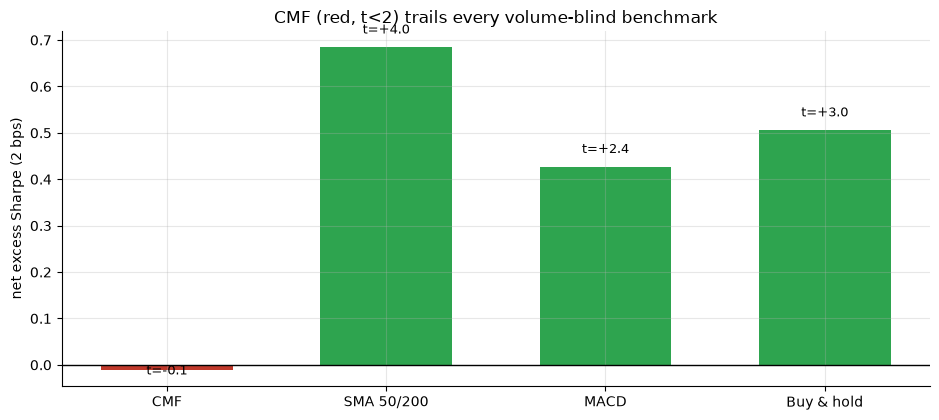

,arm,net_sharpe,hac_t
0,CMF,-0.011,-0.056
1,SMA 50/200,0.684,4.001
2,MACD,0.427,2.442
3,Buy & hold,0.505,3.016


In [2]:
if HAVE_REAL:
    b = load('SPY')
    res = st.run_experiment(b, window=20, cmf_thr=0.0, cost_bps=2.0, perm_iter=2000)
    arms = ['cmf','sma','macd','buy_hold']
    sh = [res[a]['net']['sharpe'] for a in arms]
    tt = [res[a]['net']['hac_t'] for a in arms]
else:
    sh = [-0.011, 0.684, 0.427, 0.505]
    tt = [-0.056, 4.001, 2.442, 3.016]
labels = ['CMF','SMA 50/200','MACD','Buy & hold']
fig, ax = plt.subplots(figsize=(9.5, 4.3))
cols = [RED if t < 2 else GREEN for t in tt]
ax.bar(labels, sh, color=cols, width=.6)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('net excess Sharpe (2 bps)')
ax.set_title('CMF (red, t<2) trails every volume-blind benchmark')
for i,(s,t) in enumerate(zip(sh,tt)):
    ax.text(i, s + .02*np.sign(s) + .01, f't={t:+.1f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()
pd.DataFrame({'arm':labels,'net_sharpe':np.round(sh,3),'hac_t':np.round(tt,3)})

> In plain words: CMF nets Sharpe **-0.01** at HAC *t* **-0.06** — statistically a flat zero. The SMA filter clears *t* = **+4.0**; CMF trails it by **-0.69** Sharpe. The volume weighting buys nothing the price trend didn't already give you — for less.

### 4b · The permutation placebo — is the timing informative?

Scramble the CMF position in 21-day blocks against the realised returns 2,000 times. If the real edge sits in the bulk of the placebo cloud, the timing is noise.

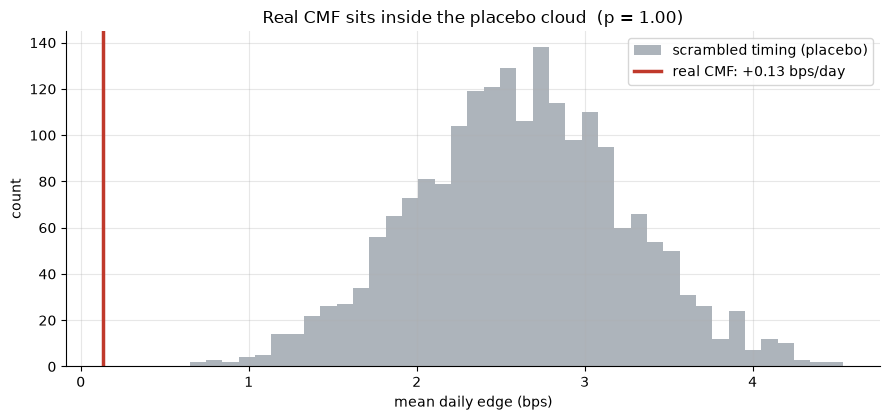

permutation p-value = 1.000


In [3]:
if HAVE_REAL:
    cmf = st.chaikin_money_flow(b, 20); pos = st.positions_from_cmf(cmf)
    ae = b['close'].astype(float).pct_change().fillna(0.0)
    rng = np.random.default_rng(419)
    posshift = pos.shift(1).fillna(0.0).to_numpy(); aev = ae.to_numpy()
    n = len(aev); blk = 21; nb_ = int(np.ceil(n/blk))
    obs = float(np.nanmean(posshift*aev))
    plac = []
    for _ in range(2000):
        order = rng.permutation(nb_)
        sh_ = np.concatenate([posshift[j*blk:(j+1)*blk] for j in order])[:n]
        plac.append(float(np.nanmean(sh_*aev)))
    plac = np.array(plac); p = (np.sum(plac>=obs)+1)/(len(plac)+1)
else:
    obs, plac, p = 0.0, np.random.default_rng(0).normal(3e-4,1e-4,2000), 1.0
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(plac*1e4, bins=40, color=GREY, alpha=.7, label='scrambled timing (placebo)')
ax.axvline(obs*1e4, c=RED, lw=2.5, label=f'real CMF: {obs*1e4:+.2f} bps/day')
ax.set_xlabel('mean daily edge (bps)'); ax.set_ylabel('count')
ax.set_title(f'Real CMF sits inside the placebo cloud  (p = {p:.2f})'); ax.legend()
plt.tight_layout(); plt.show()
print(f'permutation p-value = {p:.3f}')

> In plain words: permutation *p* = **1.00**. Knowing *when* CMF said 'be long' is worth no more than a random reshuffle of those same long-days. The signal does not lead — it rides along.

### 4c · Cost sweep — there's no break-even because gross is already ~zero


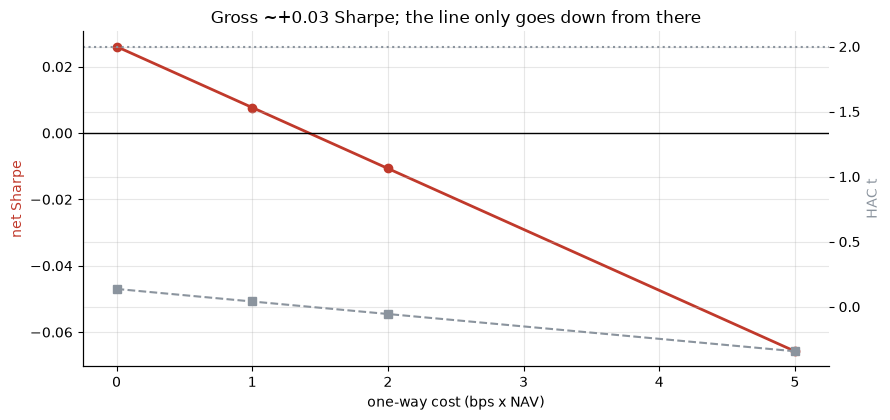

gross Sharpe +0.026 (t +0.14) -> never clears t=2 at any cost


In [4]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sw = [st.summarize_book(st.backtest(b, pos, cost_bps=c)['net_excess']) for c in costs]
    nets = [s['sharpe'] for s in sw]; tts = [s['hac_t'] for s in sw]
else:
    nets = [0.026,0.008,-0.011,-0.066]
    tts = [0.137,0.04,-0.056,-0.342]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, nets, 'o-', c=RED, lw=2, label='net excess Sharpe')
ax2 = ax.twinx(); ax2.plot(costs, tts, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('one-way cost (bps x NAV)'); ax.set_ylabel('net Sharpe', color=RED)
ax2.set_ylabel('HAC t', color=GREY)
ax.set_title('Gross ~+0.03 Sharpe; the line only goes down from there')
plt.tight_layout(); plt.show()
print(f'gross Sharpe {nets[0]:+.3f} (t {tts[0]:+.2f}) -> never clears t=2 at any cost')

### 4d · The panel — a couple of names look positive, but their *own* B&H beats CMF

If CMF led price, its Sharpe should beat each name's buy-and-hold. It never does.

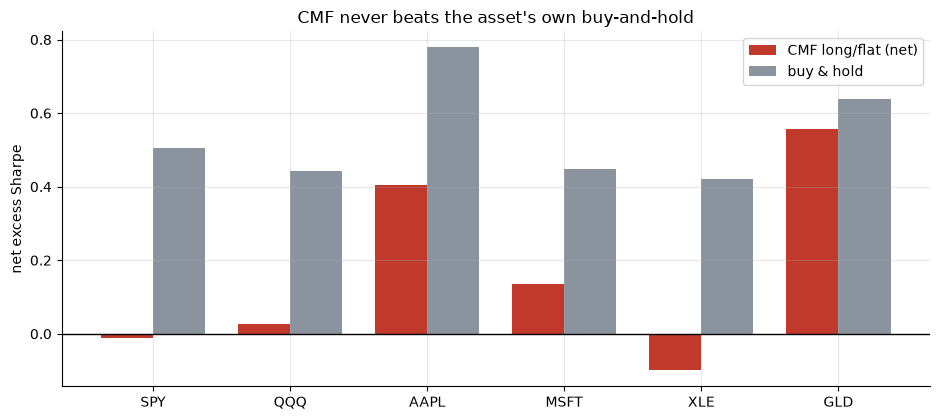

,ticker,cmf_sharpe,cmf_hac_t,bh_sharpe,cmf_minus_bh
0,SPY,-0.011,-0.056,0.505,-0.516
1,QQQ,0.027,0.136,0.443,-0.416
2,AAPL,0.405,2.033,0.779,-0.374
3,MSFT,0.135,0.704,0.447,-0.312
4,XLE,-0.099,-0.545,0.422,-0.521
5,GLD,0.558,2.609,0.638,-0.080


In [5]:
rows = []
if HAVE_REAL:
    for t in TICKERS:
        if not have(t):
            continue
        bb = load(t)
        cb = st.summarize_book(st.backtest(bb, st.positions_from_cmf(
            st.chaikin_money_flow(bb,20)), cost_bps=2.0)['net_excess'])
        bh = st.summarize_book(st.buy_hold_excess(bb))
        rows.append((t, cb['sharpe'], cb['hac_t'], bh['sharpe']))
if not rows:
    rows = list(zip(['SPY', 'QQQ', 'AAPL', 'MSFT', 'XLE', 'GLD'], [-0.011, 0.027, 0.405, 0.135, -0.099, 0.558], [-0.056, 0.136, 2.033, 0.704, -0.545, 2.609], [0.505, 0.443, 0.779, 0.447, 0.422, 0.638]))
panel = pd.DataFrame(rows, columns=['ticker','cmf_sharpe','cmf_hac_t','bh_sharpe'])
panel['cmf_minus_bh'] = panel['cmf_sharpe'] - panel['bh_sharpe']
fig, ax = plt.subplots(figsize=(9.5, 4.3))
x = np.arange(len(panel)); w = .38
ax.bar(x-w/2, panel['cmf_sharpe'], w, color=RED, label='CMF long/flat (net)')
ax.bar(x+w/2, panel['bh_sharpe'], w, color=GREY, label='buy & hold')
ax.set_xticks(x); ax.set_xticklabels(panel['ticker']); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('net excess Sharpe'); ax.legend()
ax.set_title('CMF never beats the asset\'s own buy-and-hold')
plt.tight_layout(); plt.show()
panel.round(3)

> In plain words: AAPL and GLD give CMF a positive Sharpe (and *t* near 2) — but both trended so hard that simply holding them beats the CMF book. The positive numbers are the *trend* leaking through a long-biased rule, not flow leading price.

## 5 · The verdict

- **Signal `NONE`** — CMF net excess Sharpe **-0.01**, HAC *t* **-0.06**; gross *t* **+0.14**; permutation *p* **1.00**. No instrument beats its own buy-and-hold.
- **Tradability `MIRAGE`** — loses to SMA (+0.68), MACD (+0.43) and B&H (+0.51); no positive break-even cost.
- **Does flow lead price? `NOT SUPPORTED`** — Δ vs the volume-blind SMA filter is **-0.69** Sharpe and the timing-scramble placebo matches the real signal. CMF coincides with price; it does not lead it.

## 6 · Could you trade it?

No. The gross net-excess Sharpe is ~+0.03 (HAC *t* ≈ +0.14) — inside the noise band before a cent of cost. A volume-blind SMA(50/200) filter delivers the trend-timing benefit CMF is supposed to provide, at lower turnover and a far higher Sharpe. There is no capital level or cost assumption that turns CMF-timing on SPY into an edge.

## 7 · Going further — the positive control

Is the *harness* capable of seeing a money-flow-leads-price effect? Plant one in a synthetic tape (today's volume-weighted close location forecasts tomorrow's return) and sweep the knob. CMF should pull ahead of buy-and-hold as the edge grows.

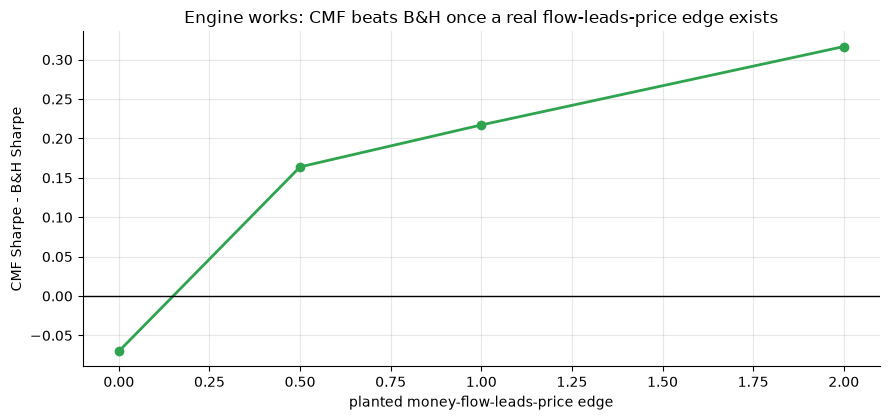

edge=0 -> delta<=0 (no edge); edge>0 -> CMF pulls ahead. The harness can see it.


In [6]:
edges = [0.0, 0.5, 1.0, 2.0]
deltas = []
for e in edges:
    sb, _ = data.synthetic_panel(n_days=4000, edge=e, seed=419)
    cmf_s = st.summarize_book(st.backtest(sb, st.positions_from_cmf(
        st.chaikin_money_flow(sb,20)), cost_bps=0.0)['net_excess'])['sharpe']
    bh_s = st.summarize_book(st.buy_hold_excess(sb))['sharpe']
    deltas.append(cmf_s - bh_s)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(edges, deltas, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted money-flow-leads-price edge'); ax.set_ylabel('CMF Sharpe - B&H Sharpe')
ax.set_title('Engine works: CMF beats B&H once a real flow-leads-price edge exists')
plt.tight_layout(); plt.show()
print('edge=0 -> delta<=0 (no edge); edge>0 -> CMF pulls ahead. The harness can see it.')

The engine is a faithful money-flow detector: with a planted lead it beats buy-and-hold; with none it does not. The real-tape verdict is therefore a statement about the **market** — on broad US equities at the daily horizon, where the close sits inside today's bar tells you nothing about tomorrow — not about the method. Forks worth trying: intraday CMF (5m), the raw Accumulation/Distribution line, or CMF *divergence* against price rather than its level.